In [1]:
# ============================================
# NOTEBOOK 05 - ANALISIS FINAL
# Aprendizaje No Supervisado e Integracion
# Evaluacion Parcial N°2 - SCY1101
# ============================================
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

from data_preprocessing import dividir_datos
from model_training import (
    entrenar_modelos_clasificacion,
    cargar_modelo,
)
from model_evaluation import evaluar_clasificacion

sns.set_theme(style="whitegrid")
print("Librerias cargadas correctamente")

Librerias cargadas correctamente


In [2]:
# ============================================
# CARGA Y PREPARACION DE DATOS
# ============================================
consultas = pd.read_parquet("../data/02_intermediate/consultas_cleaned.parquet")
pacientes = pd.read_parquet("../data/02_intermediate/pacientes_cleaned.parquet")
examenes = pd.read_parquet("../data/02_intermediate/examenes_cleaned.parquet")
medicamentos = pd.read_parquet("../data/02_intermediate/medicamentos_cleaned.parquet")

df = consultas.merge(pacientes, on="id_paciente", how="left")
df = df.merge(examenes, on="id_consulta", how="left")
df = df.merge(medicamentos, on="id_consulta", how="left")

feature_cols = [
    'id_medico', 'resultado', 'duracion_dias', 'costo_unitario',
    'id_examen', 'id_prescripcion'
]

X = df[feature_cols].fillna(0)

# Escalar datos para clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset preparado: {X_scaled.shape[0]} filas, {X_scaled.shape[1]} columnas")

Dataset preparado: 1170 filas, 6 columnas


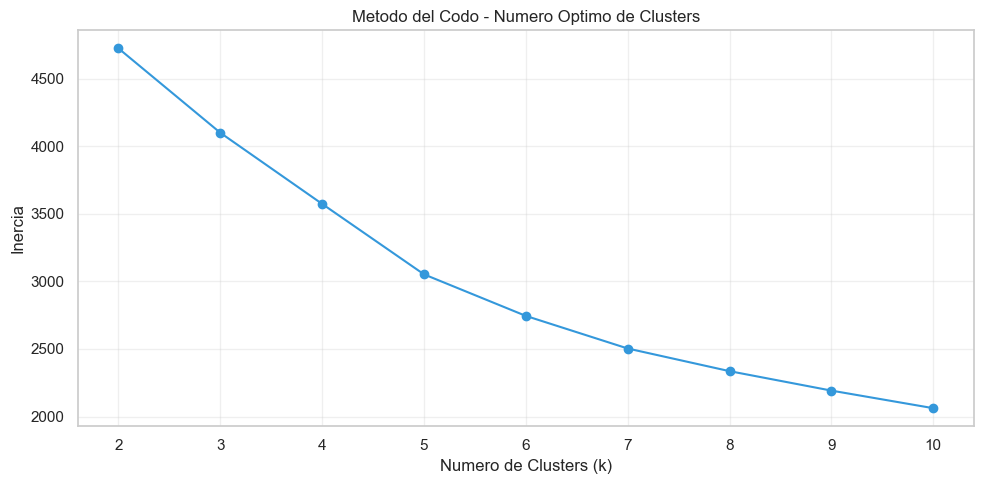

Grafico guardado


In [3]:
# ============================================
# METODO DEL CODO - NUMERO OPTIMO DE CLUSTERS
# ============================================
inercias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inercias, marker="o", color="#3498db")
plt.title("Metodo del Codo - Numero Optimo de Clusters")
plt.xlabel("Numero de Clusters (k)")
plt.ylabel("Inercia")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../src/results/plots/05_metodo_codo.png", dpi=150)
plt.show()
print("Grafico guardado")

In [4]:
# ============================================
# KMEANS - CLUSTERING
# ============================================
# Basado en el metodo del codo seleccionamos k=3
k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)

# Metricas de evaluacion
silhouette_km = silhouette_score(X_scaled, clusters_kmeans)
davies_km = davies_bouldin_score(X_scaled, clusters_kmeans)

print(f"KMeans con k={k_optimo}")
print(f"  Silhouette Score:      {silhouette_km:.4f} (mayor es mejor, max=1)")
print(f"  Davies-Bouldin Score:  {davies_km:.4f} (menor es mejor)")

# Distribucion de clusters
df['cluster_kmeans'] = clusters_kmeans
print(f"\nDistribucion de clusters:")
print(df['cluster_kmeans'].value_counts().sort_index())

KMeans con k=3
  Silhouette Score:      0.3058 (mayor es mejor, max=1)
  Davies-Bouldin Score:  1.5617 (menor es mejor)

Distribucion de clusters:
cluster_kmeans
0    298
1    284
2    588
Name: count, dtype: int64


In [5]:
# ============================================
# DBSCAN - CLUSTERING
# ============================================
dbscan = DBSCAN(eps=0.8, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_ruido = list(clusters_dbscan).count(-1)

print(f"DBSCAN resultados:")
print(f"  Clusters encontrados: {n_clusters_db}")
print(f"  Puntos de ruido:      {n_ruido}")

if n_clusters_db > 1:
    mask = clusters_dbscan != -1
    silhouette_db = silhouette_score(X_scaled[mask], clusters_dbscan[mask])
    print(f"  Silhouette Score:     {silhouette_db:.4f}")

df['cluster_dbscan'] = clusters_dbscan
print(f"\nDistribucion de clusters DBSCAN:")
print(df['cluster_dbscan'].value_counts().sort_index())

DBSCAN resultados:
  Clusters encontrados: 7
  Puntos de ruido:      341
  Silhouette Score:     0.1075

Distribucion de clusters DBSCAN:
cluster_dbscan
-1    341
 0     50
 1    746
 2      4
 3      5
 4      7
 5      9
 6      8
Name: count, dtype: int64


PCA - Varianza explicada:
  Componente 1: 38.15%
  Componente 2: 22.42%
  Total:        60.57%


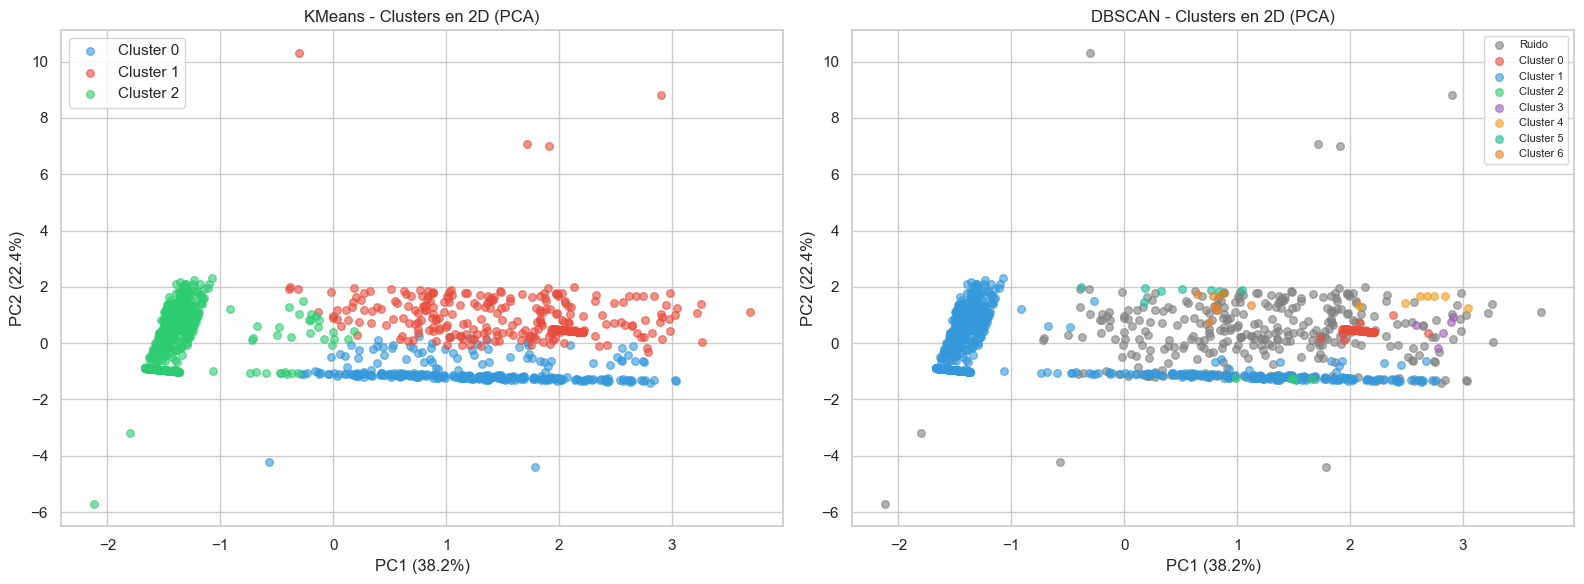

Grafico guardado


In [6]:
# ============================================
# PCA - REDUCCION DE DIMENSIONALIDAD
# ============================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza_explicada = pca.explained_variance_ratio_
print(f"PCA - Varianza explicada:")
print(f"  Componente 1: {varianza_explicada[0]*100:.2f}%")
print(f"  Componente 2: {varianza_explicada[1]*100:.2f}%")
print(f"  Total:        {varianza_explicada.sum()*100:.2f}%")

# Visualizacion clusters KMeans en 2D
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colores = ['#3498db', '#e74c3c', '#2ecc71']
for cluster in range(k_optimo):
    mask = clusters_kmeans == cluster
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colores[cluster], label=f"Cluster {cluster}",
                   alpha=0.6, s=30)

axes[0].set_title("KMeans - Clusters en 2D (PCA)")
axes[0].set_xlabel(f"PC1 ({varianza_explicada[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({varianza_explicada[1]*100:.1f}%)")
axes[0].legend()

# Visualizacion DBSCAN en 2D
colores_db = ['gray'] + ['#e74c3c', '#3498db', '#2ecc71',
              '#9b59b6', '#f39c12', '#1abc9c', '#e67e22']
for i, cluster in enumerate(sorted(set(clusters_dbscan))):
    mask = clusters_dbscan == cluster
    label = "Ruido" if cluster == -1 else f"Cluster {cluster}"
    color = colores_db[i] if i < len(colores_db) else '#333333'
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=color, label=label, alpha=0.6, s=30)

axes[1].set_title("DBSCAN - Clusters en 2D (PCA)")
axes[1].set_xlabel(f"PC1 ({varianza_explicada[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({varianza_explicada[1]*100:.1f}%)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../src/results/plots/05_clusters_pca.png", dpi=150)
plt.show()
print("Grafico guardado")

Perfil de cada cluster KMeans:
                total_pacientes  costo_promedio  duracion_dias_promedio  costo_unitario_promedio  resultado_promedio
cluster_kmeans                                                                                                      
0                           298       292462.77                   47.35                 27294.29               17.70
1                           284       275477.44                   44.46                 27322.77              197.29
2                           588       267699.83                    1.16                   533.23               85.41


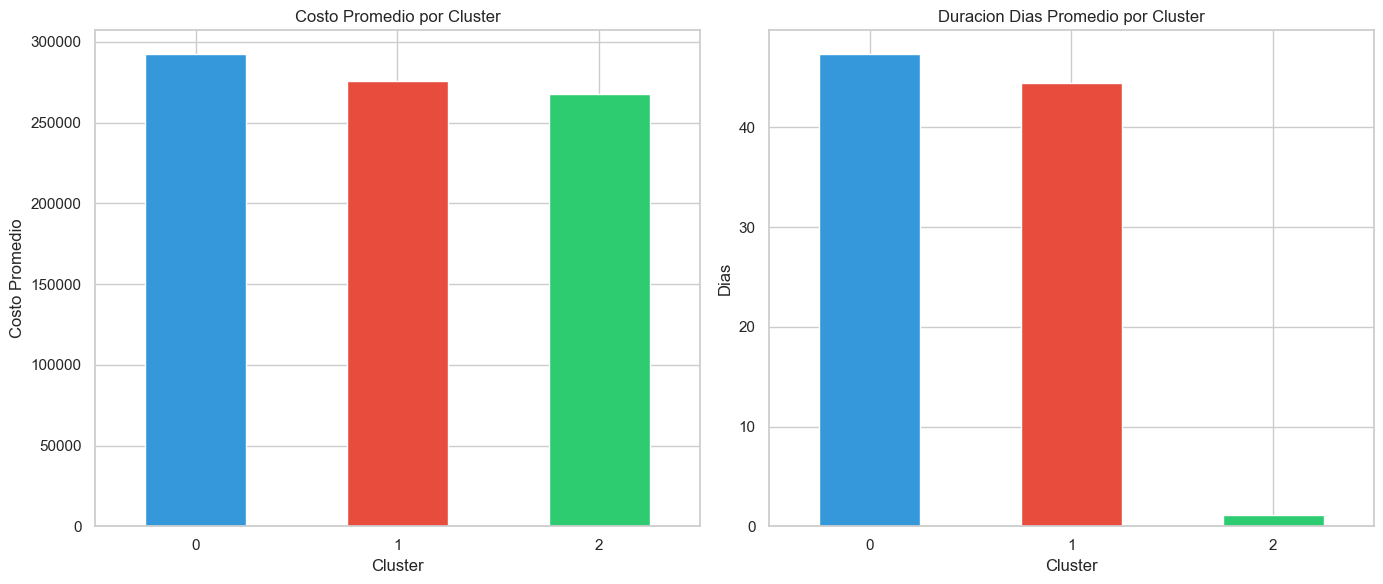

Grafico guardado


In [7]:
# ============================================
# PERFIL DE CADA CLUSTER KMEANS
# ============================================
df_cluster = df[feature_cols + ['cluster_kmeans', 'costo']].copy()
df_cluster[feature_cols] = X

perfil = df_cluster.groupby('cluster_kmeans').agg(
    total_pacientes=('costo', 'count'),
    costo_promedio=('costo', 'mean'),
    duracion_dias_promedio=('duracion_dias', 'mean'),
    costo_unitario_promedio=('costo_unitario', 'mean'),
    resultado_promedio=('resultado', 'mean'),
).round(2)

print("Perfil de cada cluster KMeans:")
print(perfil.to_string())

# Visualizacion del perfil
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

perfil['costo_promedio'].plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title("Costo Promedio por Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Costo Promedio")
axes[0].tick_params(axis='x', rotation=0)

perfil['duracion_dias_promedio'].plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_title("Duracion Dias Promedio por Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Dias")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("../src/results/plots/05_perfil_clusters.png", dpi=150)
plt.show()
print("Grafico guardado")

In [8]:
# ============================================
# RESUMEN FINAL INTEGRADO
# ============================================
# Cargar modelos optimizados
rf_optimizado = cargar_modelo("../src/models/trained_models/random_forest_optimizado.joblib")
gb_optimizado = cargar_modelo("../src/models/trained_models/gradient_boosting_optimizado.joblib")

# Preparar datos para evaluacion final
mediana_costo = df['costo'].median()
df['costo_alto'] = (df['costo'] > mediana_costo).astype(int)
X_clf = df[feature_cols].fillna(0)
y_clf = df['costo_alto']
X_train, X_test, y_train, y_test = dividir_datos(X_clf, y_clf)

# Evaluar modelos optimizados
metricas_rf = evaluar_clasificacion(rf_optimizado, X_test, y_test, "Random Forest Optimizado")
metricas_gb = evaluar_clasificacion(gb_optimizado, X_test, y_test, "Gradient Boosting Optimizado")

# Resumen no supervisado
resumen_no_supervisado = pd.DataFrame({
    "algoritmo": ["KMeans", "DBSCAN"],
    "n_clusters": [k_optimo, n_clusters_db],
    "silhouette": [silhouette_km, silhouette_db if n_clusters_db > 1 else None],
    "pca_varianza_total": [varianza_explicada.sum()*100, varianza_explicada.sum()*100],
})

resumen_no_supervisado.to_csv("../src/results/metrics/resumen_no_supervisado.csv", index=False)

print("\nResumen Final del Proyecto:")
print("="*55)
print("\nModelos Supervisados (mejores optimizados):")
print(f"  Random Forest:     Accuracy={metricas_rf['accuracy']} | F1={metricas_rf['f1_score']}")
print(f"  Gradient Boosting: Accuracy={metricas_gb['accuracy']} | F1={metricas_gb['f1_score']}")
print("\nModelos No Supervisados:")
print(resumen_no_supervisado.to_string())
print("\nTodos los resultados guardados en src/results/")

Modelo cargado desde: ../src/models/trained_models/random_forest_optimizado.joblib
Modelo cargado desde: ../src/models/trained_models/gradient_boosting_optimizado.joblib
 Train: 936 filas | Test: 234 filas

Modelo: Random Forest Optimizado
  Accuracy:  0.6538
  Precision: 0.6535
  Recall:    0.6538
  F1 Score:  0.6537

Modelo: Gradient Boosting Optimizado
  Accuracy:  0.6282
  Precision: 0.6294
  Recall:    0.6282
  F1 Score:  0.6287

Resumen Final del Proyecto:

Modelos Supervisados (mejores optimizados):
  Random Forest:     Accuracy=0.6538 | F1=0.6537
  Gradient Boosting: Accuracy=0.6282 | F1=0.6287

Modelos No Supervisados:
  algoritmo  n_clusters  silhouette  pca_varianza_total
0    KMeans           3    0.305842           60.571318
1    DBSCAN           7    0.107543           60.571318

Todos los resultados guardados en src/results/
